# 비/눈 판별 모델 v0 (일별 데이터)

**서비스에서의 역할:** 기상청 예보에 비나 눈이 있는 날, 그 강수가 **눈일 확률**을 계산한다.

```
기상청 예보 (강수 있음 + 기온·습도·풍향)  →  [이 모델]  →  "눈일 확률 72%"
```

**설계 원칙**
- 입력은 **기상청 단기예보에서도 받을 수 있는 값만** 쓴다 → 학습과 서비스에 같은 입력이 들어간다.
  (최저기온, 최고기온, 평균기온, 평균습도, 이슬점, 북서풍 여부 / 자세한 대응은 `src/first_snow/features.py`)
- 학습 데이터: 1996~2025년 **10월~4월의 강수일** (눈이 올 수 있는 시기)
- 평가: **2016년 7월 이전으로 학습 → 최근 10시즌(2016/17~2025)으로 평가.** 미래 데이터로 과거를 맞히지 않는다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, brier_score_loss, roc_auc_score
from sklearn.ensemble import HistGradientBoostingClassifier

from first_snow.data import load_daily
from first_snow.features import FEATURES, daily_features
from first_snow.model import build_model, training_set

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

df = load_daily()
days, X, y = training_set(df)

train = days["일시"] < "2016-07-01"
test = ~train
test_fall = test & days["일시"].dt.month.isin([10, 11, 12])   # 첫눈 시즌만 따로 평가

print(f"강수일 {len(y)}일 (눈 {y.sum()}일, {y.mean():.0%})")
print(f"학습 {train.sum()}일 / 평가 {test.sum()}일 (그중 10~12월 {test_fall.sum()}일)")
X.head()

강수일 2083일 (눈 730일, 35%)
학습 1390일 / 평가 693일 (그중 10~12월 337일)


,최저기온,최고기온,평균기온,평균습도,이슬점,북서풍
1,-3.9,3.9,0.2,51.5,-8.638108,0
2,-8.5,5.5,-4.5,42.3,-15.413104,1
4,-2.1,2.0,-0.1,67.0,-5.498576,0
6,0.9,5.0,2.9,88.0,1.106994,0
7,-9.4,1.8,-5.7,48.5,-14.854475,1


## 1. 후보 비교

| 지표 | 뜻 | 좋은 방향 |
|---|---|---|
| 정확도 | 확률 50% 기준으로 눈/비를 맞힌 비율 | 높을수록 |
| Brier 점수 | 예측 확률과 실제(0 또는 1)의 차이의 제곱 평균. **확률이 얼마나 믿을 만한지** | 낮을수록 |
| AUC | 눈 온 날에 더 높은 확률을 주는 능력 (0.5 = 찍기, 1 = 완벽) | 높을수록 |

서비스는 "눈일 확률 72%"처럼 **확률**을 보여줄 것이므로 Brier 점수가 특히 중요하다.

In [2]:
def scores(y_true, prob):
    return {
        "정확도": accuracy_score(y_true, prob >= 0.5),
        "Brier": brier_score_loss(y_true, prob),
        "AUC": roc_auc_score(y_true, prob),
    }


candidates = {}

# 2부에서 찾은 규칙 (확률이 아니라 0/1)
for t in [1, -1]:
    candidates[f"규칙: 최저기온 ≤ {t}°C"] = lambda Xp, t=t: (Xp["최저기온"] <= t).astype(float).to_numpy()

# 로지스틱 회귀 - Feature 조합별
for cols in [["최저기온"], ["평균기온"], ["평균기온", "이슬점"], FEATURES]:
    m = build_model().fit(X.loc[train, cols], y[train])
    name = "로지스틱: " + ("전체 Feature" if cols == FEATURES else " + ".join(cols))
    candidates[name] = lambda Xp, m=m, cols=cols: m.predict_proba(Xp[cols])[:, 1]

# 비선형 모델 (부스팅)
gbm = HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=200).fit(X[train], y[train])
candidates["부스팅: 전체 Feature"] = lambda Xp: gbm.predict_proba(Xp)[:, 1]

rows = []
for name, predict in candidates.items():
    row = {"모델": name}
    for label, mask in [("전체", test), ("10~12월", test_fall)]:
        for k, v in scores(y[mask], predict(X[mask])).items():
            row[f"{label} {k}"] = round(v, 3)
    rows.append(row)

comparison = pd.DataFrame(rows).set_index("모델")
comparison

,전체 정확도,전체 Brier,전체 AUC,10~12월 정확도,10~12월 Brier,10~12월 AUC
모델,,,,,,
규칙: 최저기온 ≤ 1°C,0.861,0.139,0.877,0.843,0.157,0.881
규칙: 최저기온 ≤ -1°C,0.864,0.136,0.842,0.893,0.107,0.870
로지스틱: 최저기온,0.873,0.089,0.950,0.896,0.079,0.955
로지스틱: 평균기온,0.902,0.071,0.965,0.914,0.065,0.967
로지스틱: 평균기온 + 이슬점,0.898,0.072,0.964,0.908,0.065,0.966
로지스틱: 전체 Feature,0.903,0.071,0.965,0.917,0.065,0.966
부스팅: 전체 Feature,0.896,0.071,0.968,0.899,0.068,0.967


**읽는 법**
- 규칙(0/1)은 정확도는 괜찮지만 Brier 점수가 나쁘다. "애매한 날"에도 0% 또는 100%로 단정하기 때문이다.
- 로지스틱 회귀는 확률을 주므로 Brier 점수가 크게 좋아진다 (0.139 → 0.07 수준).
- **평균기온 하나만 써도 전체 Feature, 부스팅과 성능이 거의 같다.**
  → 일별 데이터에서는 기온 말고 더 짜낼 정보가 거의 없다는 뜻이다. 이것이 **일별 데이터의 한계**이고, 시간별 데이터가 필요한 이유다.

**v0 선택: 로지스틱 회귀 + 전체 Feature**
- 성능은 평균기온 단독과 같지만, 경계 기온대에서 이슬점(건조함)이 판단을 돕는다는 2부 분석과 맞고,
  시간별 모델(v1)과 같은 입력 구조를 유지하기 위해 전체 Feature를 쓴다.

## 2. 확률을 믿을 수 있나? (보정 곡선)

모델이 "70%"라고 한 날들을 모았을 때 실제로 70% 정도 눈이 왔다면, 확률을 믿을 수 있는 모델이다.

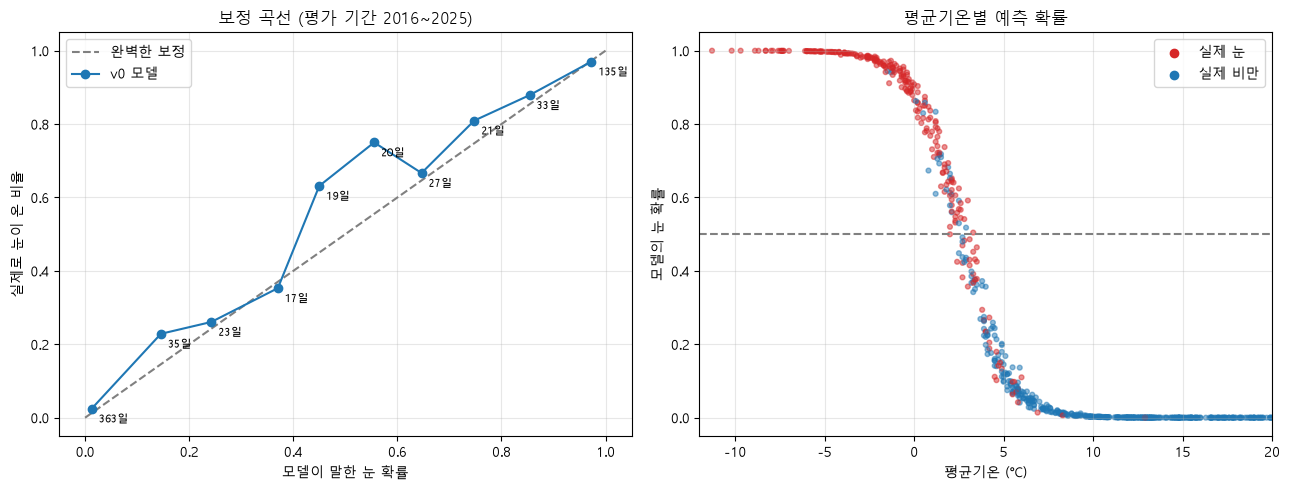

In [3]:
model = build_model().fit(X[train], y[train])
prob = model.predict_proba(X[test])[:, 1]

bins = np.linspace(0, 1, 11)
idx = np.digitize(prob, bins[1:-1])
calib = pd.DataFrame({"예측": prob, "실제": y[test].to_numpy(), "구간": idx}).groupby("구간").agg(
    평균예측=("예측", "mean"), 실제비율=("실제", "mean"), 일수=("실제", "size"))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot([0, 1], [0, 1], "--", color="gray", label="완벽한 보정")
ax.plot(calib["평균예측"], calib["실제비율"], marker="o", label="v0 모델")
for _, r in calib.iterrows():
    ax.annotate(f"{int(r['일수'])}일", (r["평균예측"], r["실제비율"]), fontsize=8,
                textcoords="offset points", xytext=(5, -10))
ax.set_xlabel("모델이 말한 눈 확률")
ax.set_ylabel("실제로 눈이 온 비율")
ax.set_title("보정 곡선 (평가 기간 2016~2025)")
ax.legend()
ax.grid(alpha=0.3)

# 평균기온에 따른 예측 확률
ax = axes[1]
colors = np.where(y[test] == 1, "tab:red", "tab:blue")
ax.scatter(X.loc[test, "평균기온"], prob, c=colors, s=12, alpha=0.5)
ax.scatter([], [], c="tab:red", label="실제 눈")
ax.scatter([], [], c="tab:blue", label="실제 비만")
ax.axhline(0.5, color="gray", linestyle="--")
ax.set_xlabel("평균기온 (°C)")
ax.set_ylabel("모델의 눈 확률")
ax.set_title("평균기온별 예측 확률")
ax.set_xlim(-12, 20)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. 무엇을 틀렸나

첫눈 시즌(10~12월) 평가 기간에서 모델이 가장 크게 틀린 날들을 기사와 함께 본다.

In [4]:
fall = days[test_fall].copy()
fall["눈 확률"] = model.predict_proba(X[test_fall])[:, 1].round(2)
fall["실제"] = np.where(fall["눈"], "눈", "비만")
fall["오차"] = (fall["눈 확률"] - fall["눈"].astype(int)).abs()

cols = ["일시", "실제", "눈 확률", "최저기온(°C)", "평균기온(°C)", "최고기온(°C)"]
worst = fall.sort_values("오차", ascending=False).head(10)
pd.set_option("display.max_colwidth", 80)
worst[cols + ["기사"]].assign(기사=worst["기사"].str.slice(0, 80))

,일시,실제,눈 확률,최저기온(°C),평균기온(°C),최고기온(°C),기사
9829,2022-11-29,눈,0.01,-1.6,6.9,15.0,-{비}-{시정(미만)}{1km}{비}0113-{시정(이상)}{1km}{비}0137-{비}{강도0}0300-{비}{강도0}0600-063...
10557,2024-11-26,눈,0.04,1.0,5.8,12.7,{박무}0205-{박무}{강도0}0300-{박무}{강도0}0600-0615. -{비}-{비}{강도1}0300-{비}{강도1}0600-08...
8008,2017-12-04,비만,0.94,-6.1,-1.2,4.5,{비}0240-{비}{강도0}0300-0430. -{박무}-{박무}{강도1}0300-{박무}{강도1}0600-0655. {연무}0650-...
9465,2021-11-30,눈,0.07,0.7,5.7,8.9,{비}0405-{비}{강도1}0600-{비}{강도0}0900-{비}{강도0}1200-1320. {박무}0430-{박무}{강도1}0600-...
9110,2020-12-10,눈,0.08,3.2,5.8,9.3,{눈}0355-{진눈깨비}0545-{진눈깨비}{강도0}0600-0630. {연무}1420-{연무}{강도0}1500-{연무}{강도0}180...
8722,2019-11-18,눈,0.10,0.4,4.6,12.7,-{박무}-0255. -{비}-{비}{강도1}0300-0355. {황사}1055-{황사}{강도0}1200-{황사}{강도0}1500-174...
8719,2019-11-15,눈,0.10,1.4,5.6,7.6,{진눈깨비}0150-{비}0240-{비}{강도0}0300-0315. {비}0510-{비}{강도0}0600-{소나기}0605-{비}0640...
9837,2022-12-07,눈,0.13,1.2,4.9,9.0,{눈}0050-{눈}{강도0}0300-{진눈깨비}0320-0410.
10592,2024-12-31,비만,0.86,-2.0,0.6,4.9,-{비}-0020. {연무}0050-0110. -{박무}-0055.
10587,2024-12-26,비만,0.86,-4.8,0.1,4.2,-{박무}-{박무}{강도0}0300-{박무}{강도0}0600-0705. {비}0355-0410. {연무}0701-{연무}{강도0}0900...


## 3-2. 첫눈 날은 잘 맞히나?

서비스의 목적은 **첫눈**을 알리는 것이므로, 평가 기간(2016~2025) 각 해의 첫눈 날에 모델이 준 확률을 따로 본다.

In [5]:
from first_snow.data import first_snow_dates

fs = first_snow_dates(df)
fs_test = fs[fs["일시"] >= "2016-07-01"].copy()
fs_test["눈 확률"] = model.predict_proba(daily_features(fs_test))[:, 1].round(2)

print(f"첫눈 {len(fs_test)}번 중 확률 50% 이상: {(fs_test['눈 확률'] >= 0.5).sum()}번")
fs_test[["일시", "눈 확률", "최저기온(°C)", "평균기온(°C)", "최고기온(°C)"]].assign(
    기사=fs_test["기사"].str.slice(0, 70))

첫눈 10번 중 확률 50% 이상: 5번


,일시,눈 확률,최저기온(°C),평균기온(°C),최고기온(°C),기사
20,2016-11-26,0.84,-0.7,0.9,2.7,{눈}1119-{눈}{강도0}1200-{시정(미만)}{1km}{눈}1355-{시정(이상)}{1km}{눈}1433-{눈}{강도0
21,2017-11-17,0.59,-1.6,3.0,5.8,{비}1435-1455. {비}1520-1550. {눈}1740- {진눈깨비}1755-{진눈깨비}{강도0}1800-1820.
22,2018-11-24,0.58,0.3,2.6,3.8,{진눈깨비}0410-0425. {눈}0615-{시정(미만)}{1km}{눈}0645-{시정(미만)}{0.5km}{눈}0730-{
23,2019-11-15,0.10,1.4,5.6,7.6,{진눈깨비}0150-{비}0240-{비}{강도0}0300-0315. {비}0510-{비}{강도0}0600-{소나기}0605-{
24,2020-12-10,0.08,3.2,5.8,9.3,{눈}0355-{진눈깨비}0545-{진눈깨비}{강도0}0600-0630. {연무}1420-{연무}{강도0}1500-{연무}{강
25,2021-11-10,0.20,0.7,4.2,7.7,{눈}0610-{진눈깨비}0645-0850. {박무}0635-0710. {비}1745-{비}{강도0}1800-1835. {비}
26,2022-11-29,0.01,-1.6,6.9,15.0,-{비}-{시정(미만)}{1km}{비}0113-{시정(이상)}{1km}{비}0137-{비}{강도0}0300-{비}{강도0}06
27,2023-11-17,0.67,-1.9,1.6,5.9,{비}0010-0110. -{박무}-0135. {눈}1125-1150. {눈}1250-1320.
28,2024-11-26,0.04,1.0,5.8,12.7,{박무}0205-{박무}{강도0}0300-{박무}{강도0}0600-0615. -{비}-{비}{강도1}0300-{비}{강도1}0
29,2025-12-04,0.98,-9.4,-3.2,3.5,{눈}1715-{눈}{강도0}1800-{시정(미만)}{1km}{눈}1837-{시정(미만)}{0.5km}{눈}1849-{시정(이


## 4. 정리

**잘 되는 것**
- v0 모델(로지스틱 회귀)은 최근 10시즌 강수일 전체에서 **정확도 약 90%, AUC 0.97**이다.
- 규칙(최저기온 ≤ 1°C)보다 확률의 신뢰도(Brier)가 약 2배 좋고, 보정 곡선도 대각선 근처다 → "눈일 확률"을 보여줄 수 있다.

**⚠️ 문제: 정작 첫눈을 잘 못 맞힌다**
- 평가 기간 첫눈 10번 중 **확률 50% 이상을 준 건 5번뿐**이다.
- 놓친 첫눈(2019, 2020, 2021, 2022, 2024)은 모두 **새벽에 잠깐 눈·진눈깨비가 오고 낮에는 풀린 날**이다. 하루 평균기온이 4~7°C라서 모델은 "비"로 판단했다.
- 전체 정확도 90%는 대부분 한겨울의 뻔한 눈(영하의 날)과 가을의 뻔한 비 덕분이다. **첫눈은 원래 경계에 있는 사건**이라 일별 평균으로는 잡기 어렵다.
- 평균기온 하나만 써도 전체 Feature와 성능이 같다 → 일별 데이터로는 여기가 한계다.

**다음 (v1): 시간별 데이터**
- ASOS **시간별** 관측으로 "강수가 내린 그 시간의 기온·습도"를 써서 다시 학습한다.
- 예) 2020-12-10은 하루 평균 5.8°C였지만, 눈이 온 03:55~06:30의 기온은 훨씬 낮았을 것이다.
- 기상청 단기예보도 1시간 단위라서 서비스에 그대로 연결할 수 있다.
- **v1의 목표: 첫눈 10번 중 5번보다 많이 맞히기.**
